# National Real Estate Prices (Python Notebook)

This notebook mirrors the original `Final Project.Rmd` flow chunk-by-chunk using Python.

## 1) Read data
Equivalent to the first R chunk (`read.csv` calls). This notebook assumes files are in `data/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.stats import linregress
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

BASE_DIR = Path.cwd()
if not (BASE_DIR / "data").exists() and (BASE_DIR / "national-real-estate-prices-python").exists():
    BASE_DIR = BASE_DIR / "national-real-estate-prices-python"

DATA_DIR = BASE_DIR / "data"
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

cpi = pd.read_csv(DATA_DIR / "CPI-U.csv")
mortgage_rates = pd.read_csv(DATA_DIR / "30_year_mortgate_rates.csv")
housing_usa = pd.read_csv(DATA_DIR / "Housing_Index_USA.csv")
housing_mountain = pd.read_csv(DATA_DIR / "Housing_Index_Mountain.csv")
housing_colorado = pd.read_csv(DATA_DIR / "Housing_Index_Colorado.csv")
housing_denver = pd.read_csv(DATA_DIR / "Housing_Index_Denver.csv")
housing_boulder = pd.read_csv(DATA_DIR / "Housing_Index_Boulder.csv")

for name, frame in {
    "CPI": cpi,
    "Mortgage_Rates": mortgage_rates,
    "Housing_USA": housing_usa,
    "Housing_Mountain": housing_mountain,
    "Housing_Colorado": housing_colorado,
    "Housing_Denver": housing_denver,
    "Housing_Boulder": housing_boulder,
}.items():
    print(f"{name}: shape={frame.shape}")
    display(frame.head(3))

CPI: shape=(662, 3)


,Year,Month,Index
0,1971,1,39.9
1,1971,2,39.9
2,1971,3,40.0


Mortgage_Rates: shape=(661, 3)


,Year,Month,Rate
0,1971,4,7.31
1,1971,5,7.42
2,1971,6,7.53


Housing_USA: shape=(421, 3)


...

,Year,Quarter,Index
0,1975,1,54.56
1,1975,2,54.58
2,1975,3,55.45


Housing_Denver: shape=(199, 3)


,Year,Quarter,Index
0,1976,2,31.98
1,1976,3,31.70
2,1976,4,32.66


Housing_Boulder: shape=(192, 3)


,Year,Quarter,Index
0,1978,1,35.34
1,1978,2,36.85
2,1978,3,38.34


## 2) Convert to fractional year, visualize, merge monthly USA/Mountain + CPI + Mortgage
Equivalent to the large ggplot/merge/scatter R chunk.

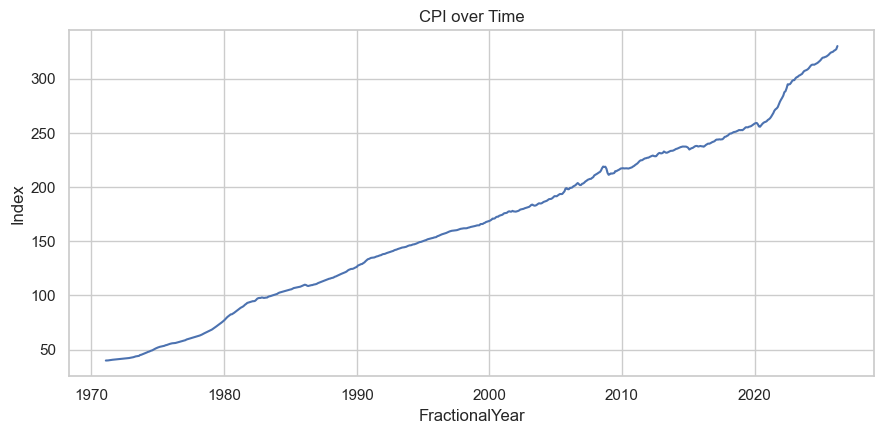

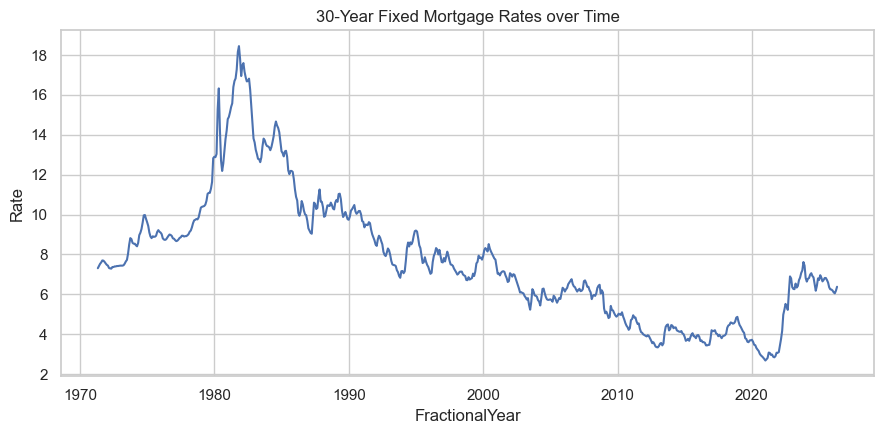

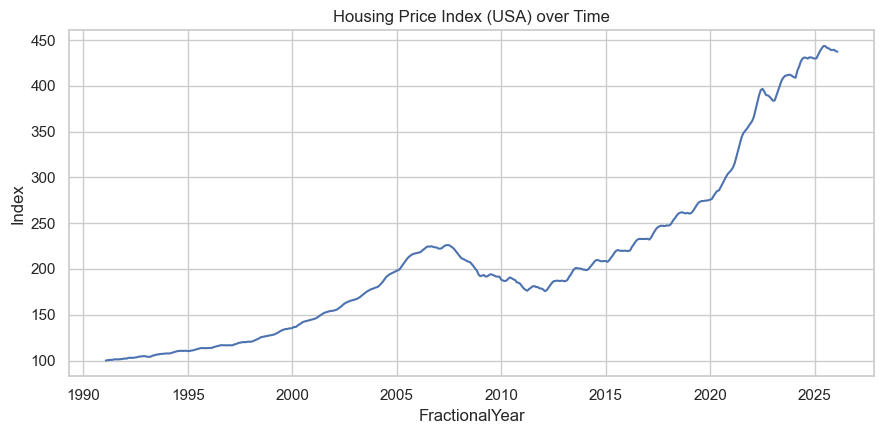

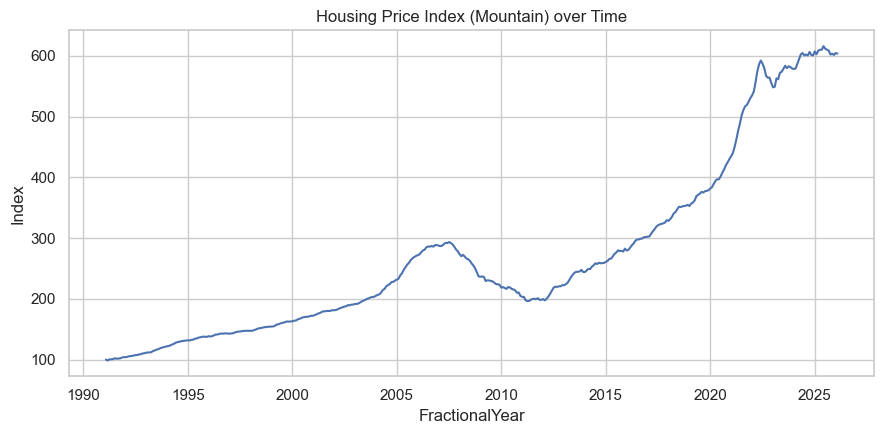

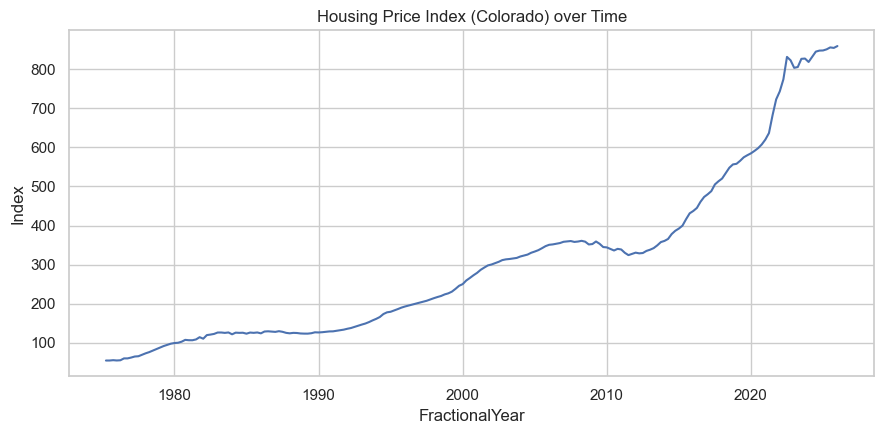

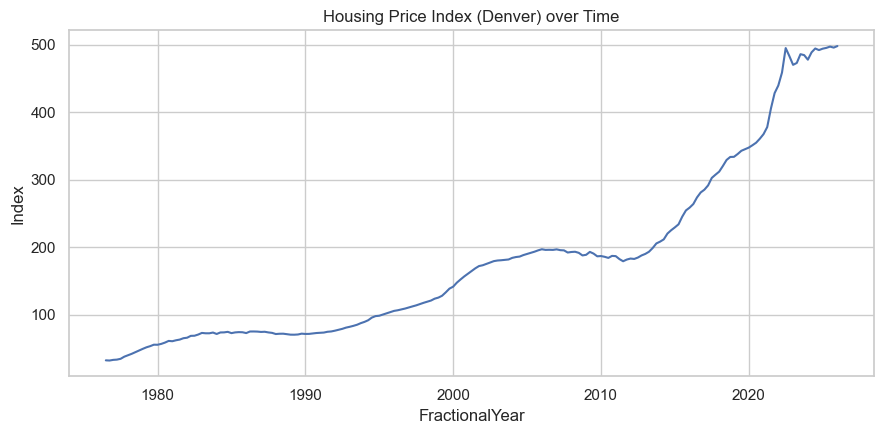

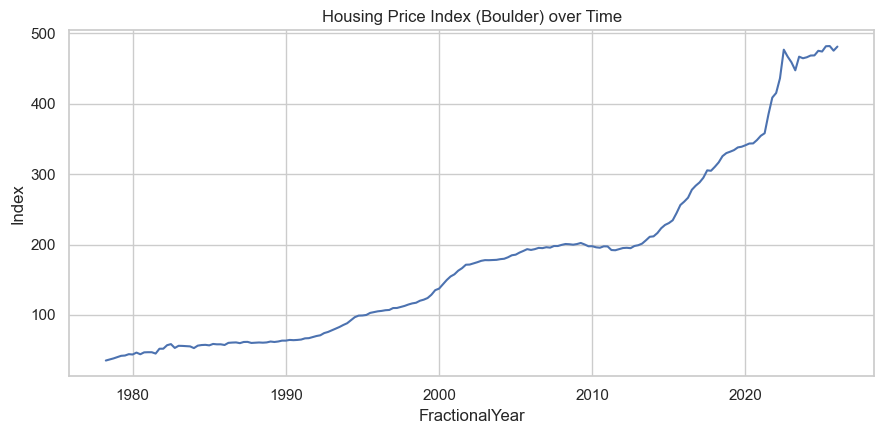

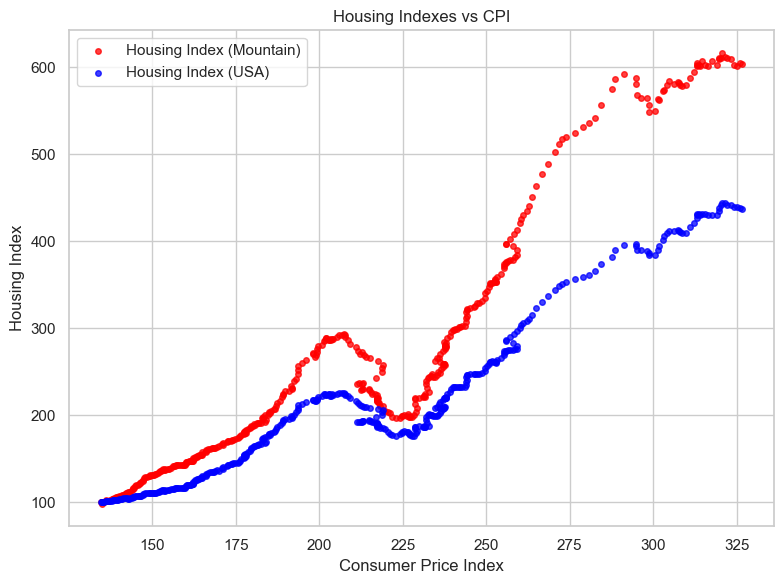

In [2]:
# Convert Year/Month to FractionalYear
cpi["FractionalYear"] = cpi["Year"] + cpi["Month"] / 12
mortgage_rates["FractionalYear"] = mortgage_rates["Year"] + mortgage_rates["Month"] / 12
housing_usa["FractionalYear"] = housing_usa["Year"] + housing_usa["Month"] / 12
housing_mountain["FractionalYear"] = housing_mountain["Year"] + housing_mountain["Month"] / 12

# Convert Year/Quarter to FractionalYear
housing_colorado["FractionalYear"] = housing_colorado["Year"] + housing_colorado["Quarter"] / 4
housing_denver["FractionalYear"] = housing_denver["Year"] + housing_denver["Quarter"] / 4
housing_boulder["FractionalYear"] = housing_boulder["Year"] + housing_boulder["Quarter"] / 4

# Time-series plots
plot_specs = [
    (cpi, "Index", "CPI over Time", "line_cpi_notebook.png"),
    (mortgage_rates, "Rate", "30-Year Fixed Mortgage Rates over Time", "line_mortgage_notebook.png"),
    (housing_usa, "Index", "Housing Price Index (USA) over Time", "line_hpi_usa_notebook.png"),
    (housing_mountain, "Index", "Housing Price Index (Mountain) over Time", "line_hpi_mountain_notebook.png"),
    (housing_colorado, "Index", "Housing Price Index (Colorado) over Time", "line_hpi_colorado_notebook.png"),
    (housing_denver, "Index", "Housing Price Index (Denver) over Time", "line_hpi_denver_notebook.png"),
    (housing_boulder, "Index", "Housing Price Index (Boulder) over Time", "line_hpi_boulder_notebook.png"),
]

for frame, y_col, title, fname in plot_specs:
    plt.figure(figsize=(9, 4.5))
    sns.lineplot(data=frame, x="FractionalYear", y=y_col)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / fname, dpi=140)
    plt.show()

# Merge CPI + USA + Mountain + Mortgage
df = cpi.merge(housing_usa, on="FractionalYear", suffixes=("_CPI", "_USA"))
df = df.merge(housing_mountain, on="FractionalYear", suffixes=("", "_MOUNTAIN"))
df = df.merge(mortgage_rates, on="FractionalYear", suffixes=("", "_MORT"))
df = df[["FractionalYear", "Index_CPI", "Index_USA", "Index", "Rate"]].copy()
df.columns = ["Year", "CPI", "HousingIndex_USA", "HousingIndex_Mountain", "Mortgage_Rate"]

# Scatter (USA + Mountain vs CPI)
plt.figure(figsize=(8, 6))
plt.scatter(df["CPI"], df["HousingIndex_Mountain"], s=16, alpha=0.75, label="Housing Index (Mountain)", color="red")
plt.scatter(df["CPI"], df["HousingIndex_USA"], s=16, alpha=0.75, label="Housing Index (USA)", color="blue")
plt.xlabel("Consumer Price Index")
plt.ylabel("Housing Index")
plt.legend()
plt.title("Housing Indexes vs CPI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_housing_usa_mountain_vs_cpi_notebook.png", dpi=140)
plt.show()

## 3) Merge CPI + Mortgage into `df1` (monthly)
Equivalent to the R chunk creating `df1`.

In [3]:
df1 = cpi.merge(mortgage_rates, on="FractionalYear", suffixes=("_CPI", "_MORT"))
df1 = df1[["FractionalYear", "Index", "Rate"]].copy()
df1.columns = ["Year", "CPI", "Mortgage_Rate"]
display(df1.head())

,Year,CPI,Mortgage_Rate
0,1971.333333,40.1,7.31
1,1971.416667,40.3,7.42
2,1971.500000,40.5,7.53
3,1971.583333,40.6,7.60
4,1971.666667,40.7,7.70


## 4) Build `df2` (quarterly Colorado, Denver, Boulder + CPI + Mortgage)
Equivalent to the R chunk creating/scattering `df2`.

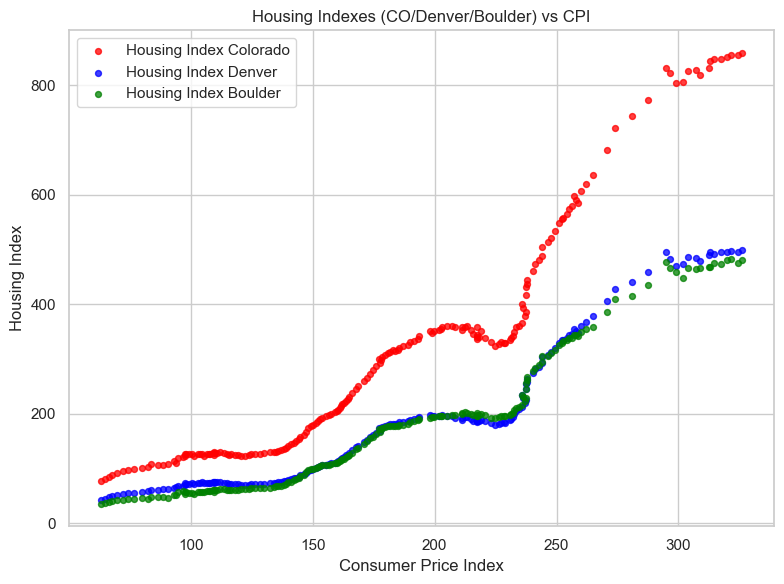

In [4]:
df2 = cpi.merge(housing_colorado, on="FractionalYear", suffixes=("_CPI", "_CO"))
df2 = df2.merge(housing_denver, on="FractionalYear", suffixes=("", "_DEN"))
df2 = df2.merge(housing_boulder, on="FractionalYear", suffixes=("", "_BOU"))
df2 = df2.merge(mortgage_rates, on="FractionalYear", suffixes=("", "_MORT"))
df2 = df2[["FractionalYear", "Index_CPI", "Index_CO", "Index", "Index_BOU", "Rate"]].copy()
df2.columns = ["Year", "CPI", "HousingIndex_Colorado", "HousingIndex_Denver", "HousingIndex_Boulder", "Mortgage_Rate"]

plt.figure(figsize=(8, 6))
plt.scatter(df2["CPI"], df2["HousingIndex_Colorado"], s=18, alpha=0.75, label="Housing Index Colorado", color="red")
plt.scatter(df2["CPI"], df2["HousingIndex_Denver"], s=18, alpha=0.75, label="Housing Index Denver", color="blue")
plt.scatter(df2["CPI"], df2["HousingIndex_Boulder"], s=18, alpha=0.75, label="Housing Index Boulder", color="green")
plt.xlabel("Consumer Price Index")
plt.ylabel("Housing Index")
plt.legend()
plt.title("Housing Indexes (CO/Denver/Boulder) vs CPI")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "scatter_housing_co_denver_boulder_vs_cpi_notebook.png", dpi=140)
plt.show()

## 5) Derive inflation rates and build `df3`
Equivalent to the long inflation loop chunk in R.

In [5]:
def annualized_inflation(series: pd.Series, periods_per_year: int) -> pd.Series:
    values = series.to_numpy(dtype=float)
    out = np.full(len(values), np.nan)
    for i in range(len(values)):
        if i < periods_per_year:
            if i + 1 < len(values):
                out[i] = periods_per_year * (values[i + 1] / values[i] - 1.0) * 100.0
        else:
            out[i] = (values[i] / values[i - periods_per_year] - 1.0) * 100.0
    return pd.Series(out, index=series.index)

# df monthly inflation
df["Consumer_Inflation_Rate"] = annualized_inflation(df["CPI"], 12)
df["House_Inflation_Rate_USA"] = annualized_inflation(df["HousingIndex_USA"], 12)
df["House_Inflation_Rate_Mountain"] = annualized_inflation(df["HousingIndex_Mountain"], 12)

# df1 monthly inflation
df1["Consumer_Inflation_Rate"] = annualized_inflation(df1["CPI"], 12)
df1 = df1[["Year", "Mortgage_Rate", "Consumer_Inflation_Rate"]]

# df2 quarterly inflation
df2["Consumer_Inflation_Rate"] = annualized_inflation(df2["CPI"], 4)
df2["House_Inflation_Rate_Colorado"] = annualized_inflation(df2["HousingIndex_Colorado"], 4)
df2["House_Inflation_Rate_Denver"] = annualized_inflation(df2["HousingIndex_Denver"], 4)
df2["House_Inflation_Rate_Boulder"] = annualized_inflation(df2["HousingIndex_Boulder"], 4)

# merge df2 + df => df3
df3 = df2.merge(df, on="Year", suffixes=("", "_monthly"))

display(df.head(3))
display(df1.head(3))
display(df2.head(3))
display(df3.head(3))

,Year,CPI,HousingIndex_USA,HousingIndex_Mountain,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain
0,1991.083333,134.7,100.00,100.00,9.64,0.890869,4.320000,-19.440000
1,1991.166667,134.8,100.36,98.38,9.36,0.000000,3.706656,24.151250
2,1991.250000,134.8,100.67,100.36,9.50,2.670623,0.000000,-0.836987


,Year,Mortgage_Rate,Consumer_Inflation_Rate
0,1971.333333,7.31,5.985037
1,1971.416667,7.42,5.955335
2,1971.500000,7.53,2.962963


,Year,CPI,HousingIndex_Colorado,HousingIndex_Denver,HousingIndex_Boulder,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder
0,1978.25,63.4,76.04,41.65,35.34,9.20,10.094637,20.462914,24.009604,17.091115
1,1978.50,65.0,79.93,44.15,36.85,9.71,9.230769,19.867384,23.918460,16.173677
2,1978.75,66.5,83.90,46.79,38.34,9.76,8.421053,16.829559,19.234879,18.779343


,Year,CPI,HousingIndex_Colorado,HousingIndex_Denver,HousingIndex_Boulder,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,CPI_monthly,HousingIndex_USA,HousingIndex_Mountain,Mortgage_Rate_monthly,Consumer_Inflation_Rate_monthly,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain
0,1991.25,134.8,130.74,73.21,66.82,9.50,4.821151,2.936777,2.779728,3.484590,134.8,100.67,100.36,9.50,2.670623,0.000000,-0.836987
1,1991.50,136.0,132.34,74.37,67.09,9.62,4.695920,3.414863,3.406563,4.420233,136.0,101.35,102.09,9.62,1.764706,-0.710409,-8.110491
2,1991.75,137.0,133.59,74.85,68.58,9.01,3.396226,3.542086,3.212907,6.193868,137.0,101.34,101.90,9.01,1.751825,2.486679,11.658489


## 6) Correlation views (replacement for `chart.Correlation`)
Equivalent to the 3 correlation-chart R chunks.

,Consumer_Inflation_Rate,Mortgage_Rate,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain
Consumer_Inflation_Rate,1.000000,0.193504,0.335417,0.292191
Mortgage_Rate,0.193504,1.000000,-0.190863,-0.167003
House_Inflation_Rate_USA,0.335417,-0.190863,1.000000,0.887425
House_Inflation_Rate_Mountain,0.292191,-0.167003,0.887425,1.000000


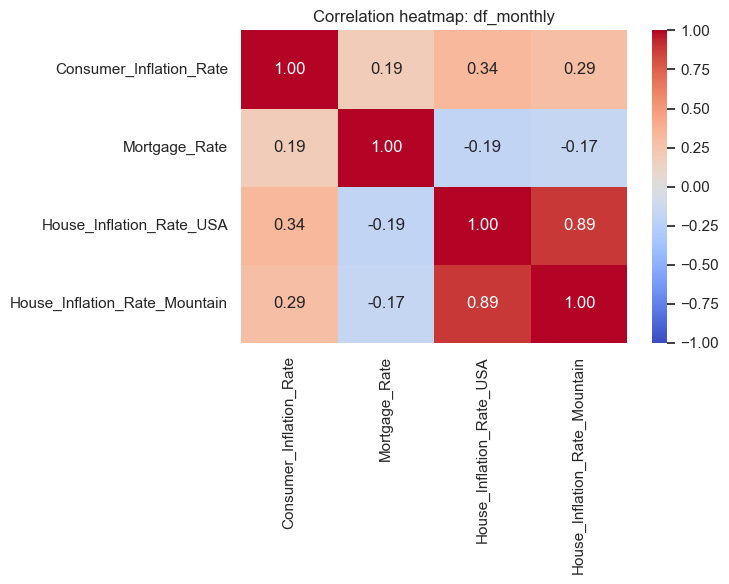

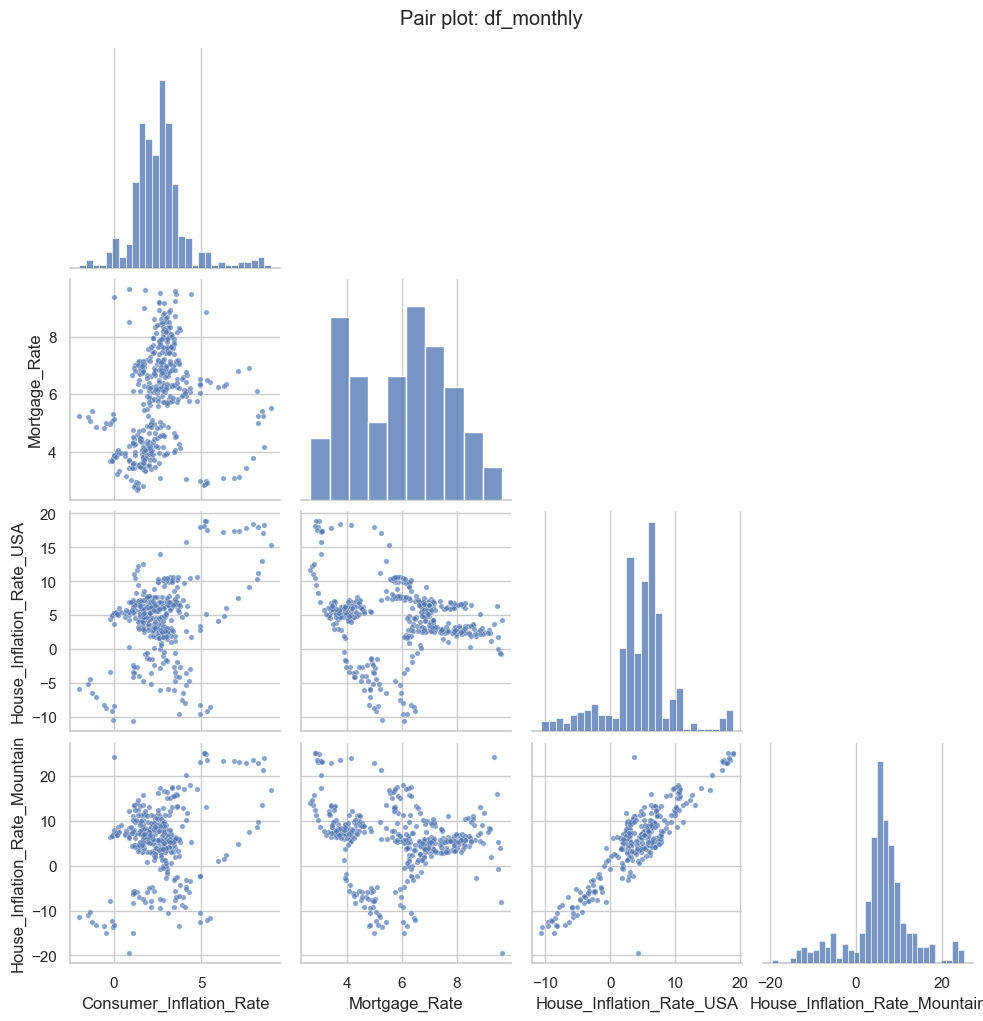

,Consumer_Inflation_Rate,Mortgage_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder
Consumer_Inflation_Rate,1.000000,0.603640,0.389466,0.385711,0.340005
Mortgage_Rate,0.603640,1.000000,-0.011817,-0.005213,0.071448
House_Inflation_Rate_Colorado,0.389466,-0.011817,1.000000,0.975144,0.888582
House_Inflation_Rate_Denver,0.385711,-0.005213,0.975144,1.000000,0.863903
House_Inflation_Rate_Boulder,0.340005,0.071448,0.888582,0.863903,1.000000


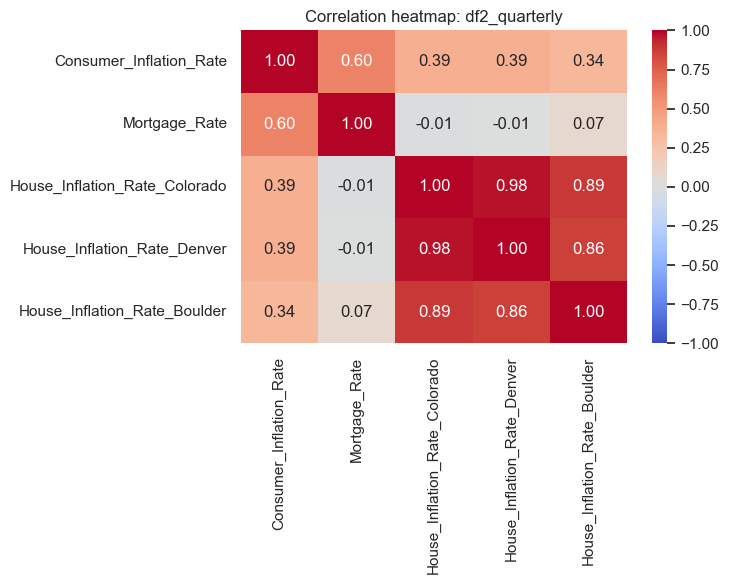

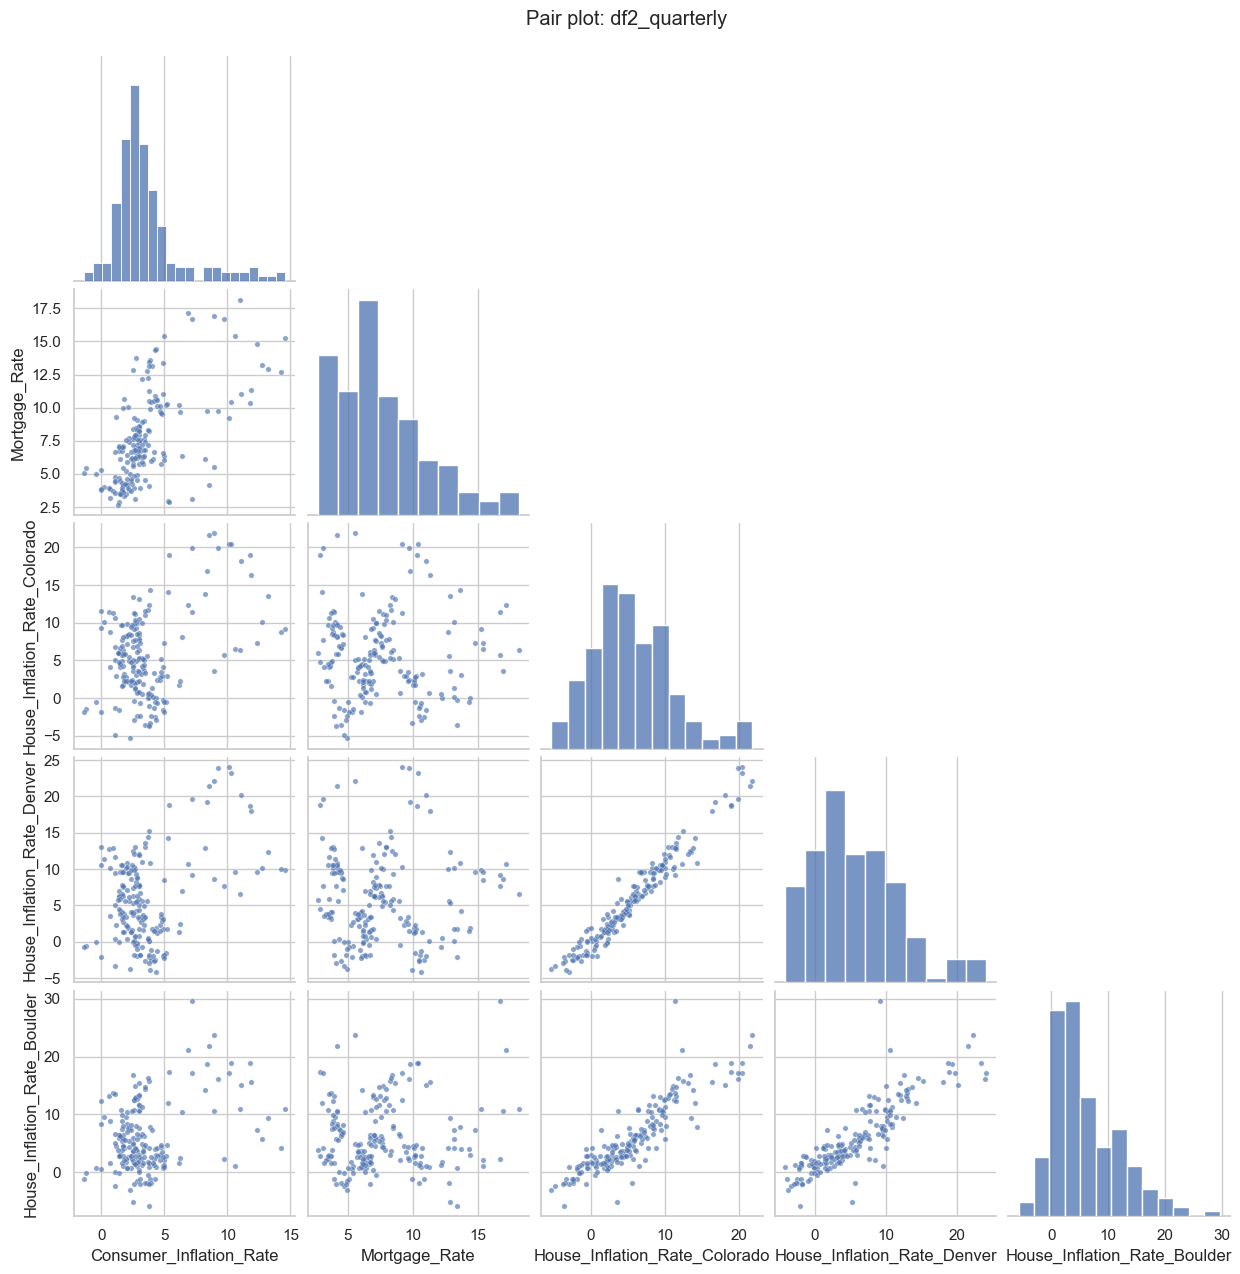

,Consumer_Inflation_Rate,Mortgage_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain
Consumer_Inflation_Rate,1.000000,0.237753,0.341180,0.248115,0.334714,0.320471,0.280052
Mortgage_Rate,0.237753,1.000000,0.021765,-0.035801,0.130116,-0.210482,-0.192147
House_Inflation_Rate_Colorado,0.341180,0.021765,1.000000,0.974176,0.944424,0.672891,0.691739
House_Inflation_Rate_Denver,0.248115,-0.035801,0.974176,1.000000,0.936181,0.641054,0.634295
House_Inflation_Rate_Boulder,0.334714,0.130116,0.944424,0.936181,1.000000,0.496415,0.539628
House_Inflation_Rate_USA,0.320471,-0.210482,0.672891,0.641054,0.496415,1.000000,0.906076
House_Inflation_Rate_Mountain,0.280052,-0.192147,0.691739,0.634295,0.539628,0.906076,1.000000


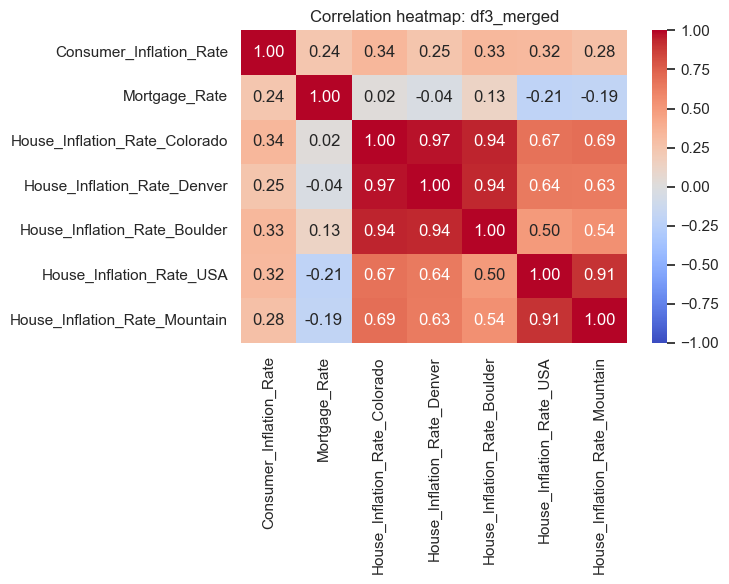

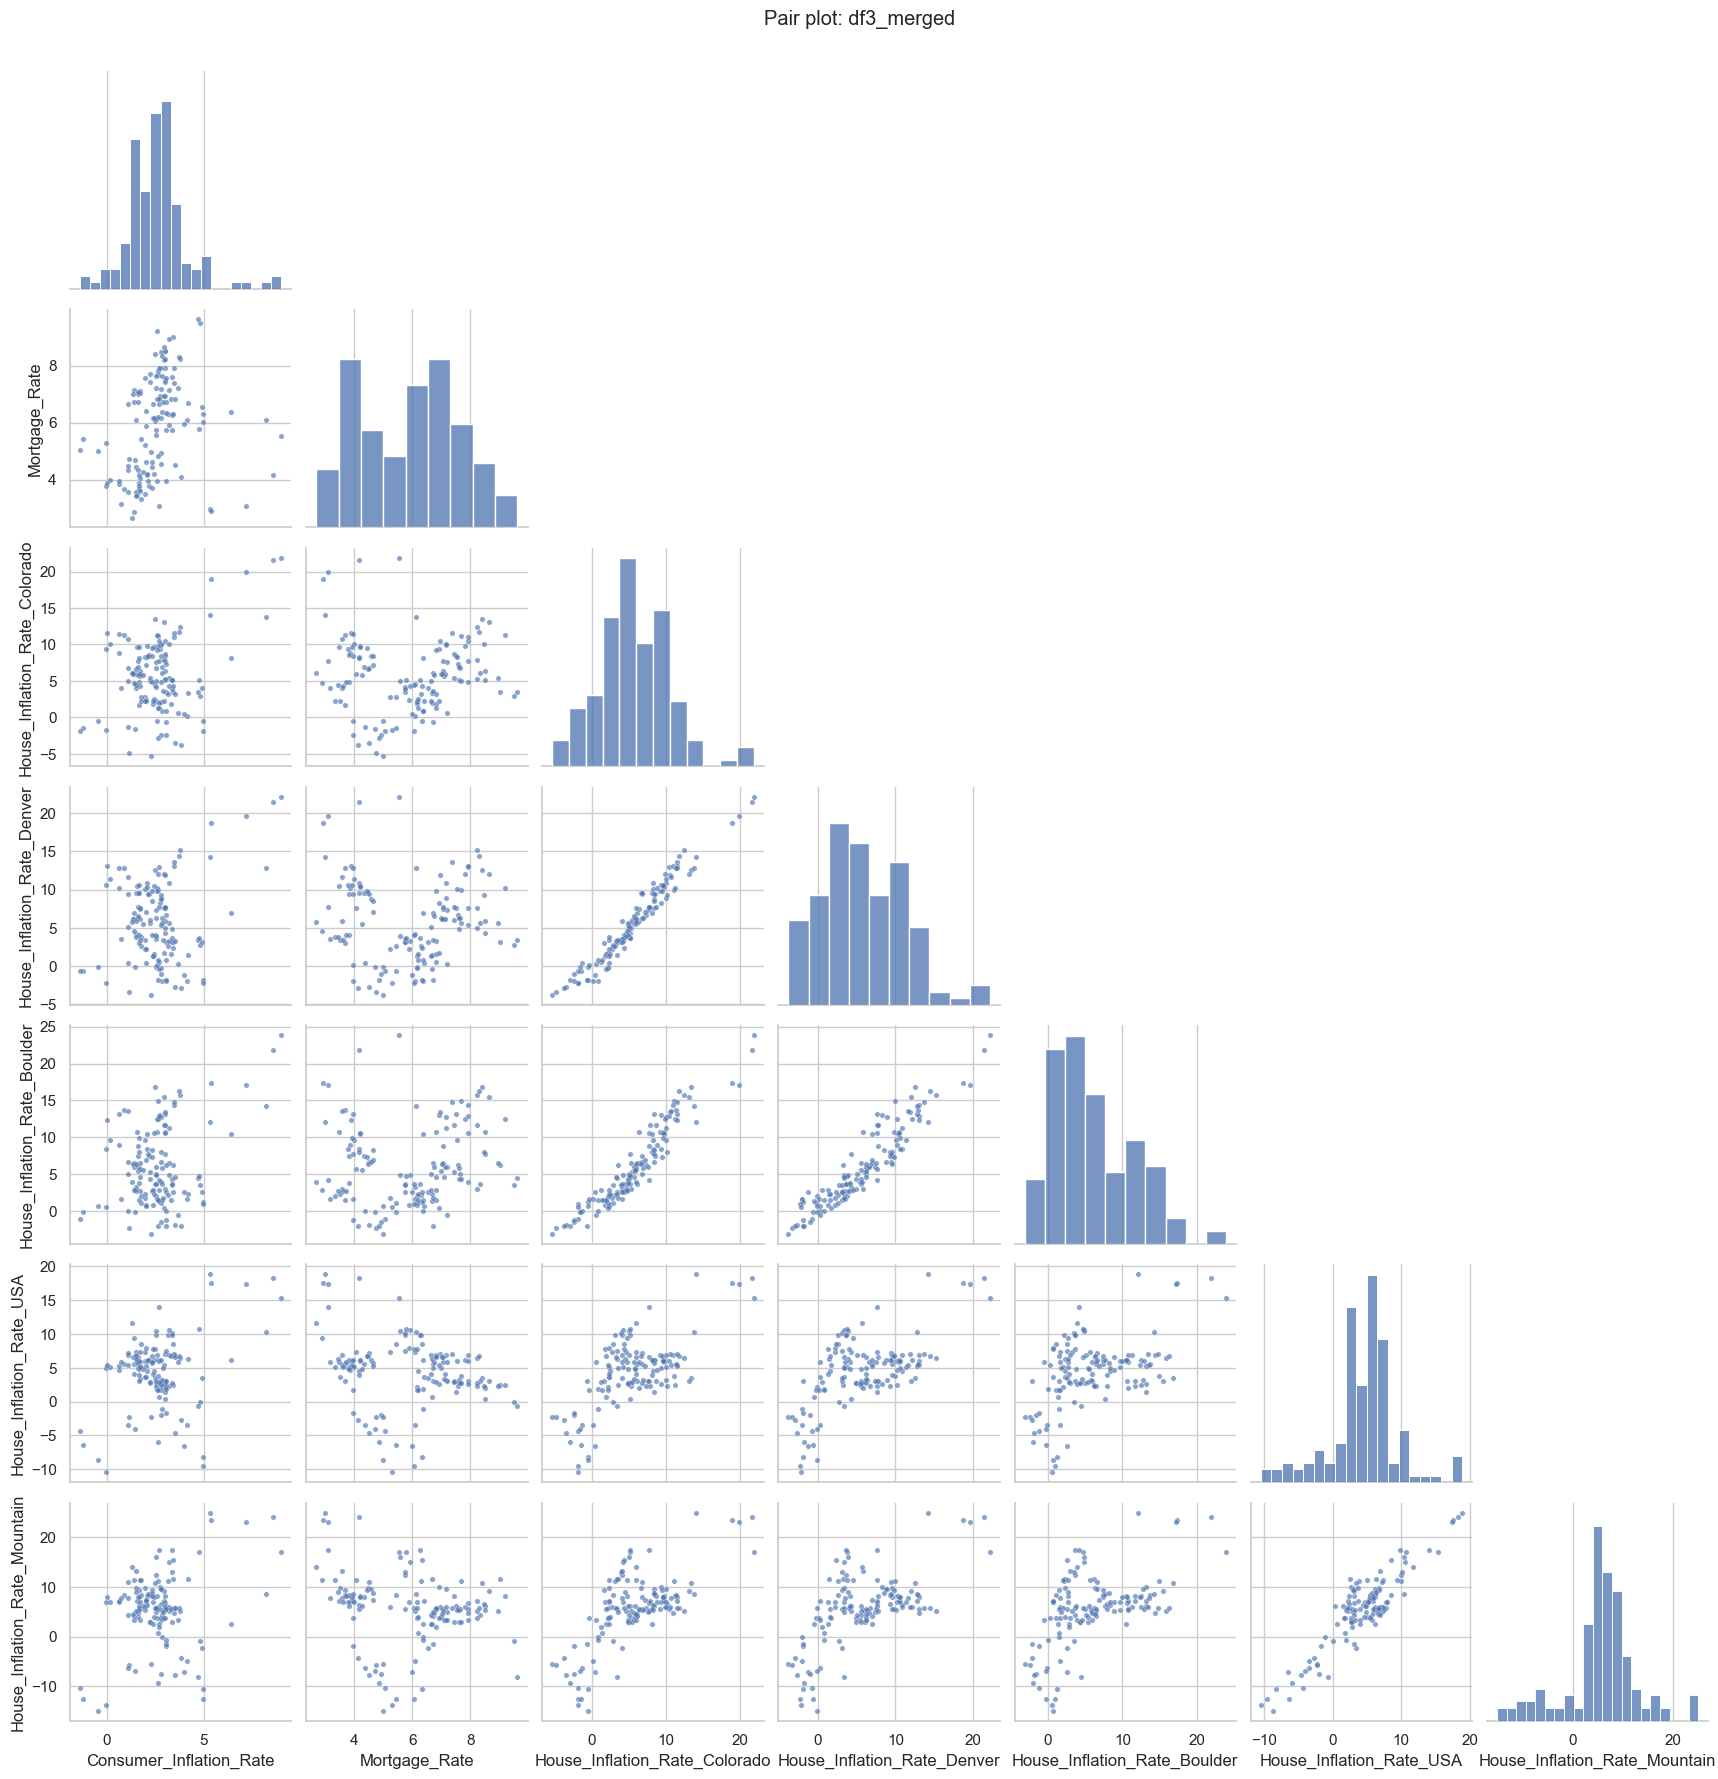

In [6]:
def correlation_views(frame: pd.DataFrame, cols: list[str], label: str):
    corr = frame[cols].corr(numeric_only=True)
    display(corr)

    plt.figure(figsize=(7.5, 6))
    sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
    plt.title(f"Correlation heatmap: {label}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{label}_corr_heatmap_notebook.png", dpi=140)
    plt.show()

    g = sns.pairplot(frame[cols].dropna(), corner=True, diag_kind="hist", plot_kws={"s": 15, "alpha": 0.65})
    g.fig.suptitle(f"Pair plot: {label}", y=1.02)
    g.savefig(OUTPUT_DIR / f"{label}_pairplot_notebook.png", dpi=140)
    plt.show()

correlation_views(df, ["Consumer_Inflation_Rate", "Mortgage_Rate", "House_Inflation_Rate_USA", "House_Inflation_Rate_Mountain"], "df_monthly")
correlation_views(df2, ["Consumer_Inflation_Rate", "Mortgage_Rate", "House_Inflation_Rate_Colorado", "House_Inflation_Rate_Denver", "House_Inflation_Rate_Boulder"], "df2_quarterly")
correlation_views(df3, ["Consumer_Inflation_Rate", "Mortgage_Rate", "House_Inflation_Rate_Colorado", "House_Inflation_Rate_Denver", "House_Inflation_Rate_Boulder", "House_Inflation_Rate_USA", "House_Inflation_Rate_Mountain"], "df3_merged")

## 7) Individual correlations/regressions for `df` (monthly)
Equivalent to the R chunk titled *Analyze individual correlations for 1991-2022 data (df, monthly)*.

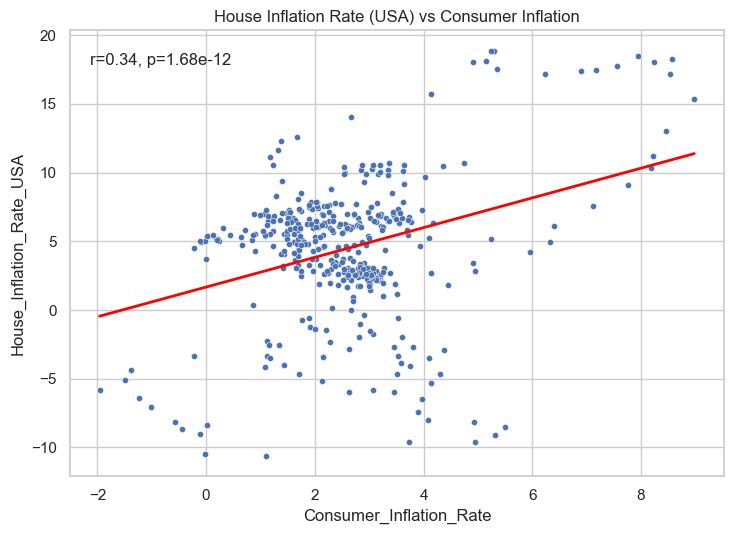

{'slope': np.float64(1.0815555381375666), 'intercept': np.float64(1.674520951713017), 'r': np.float64(0.3354165015182581), 'p': np.float64(1.676701049907687e-12), 'n': 420}


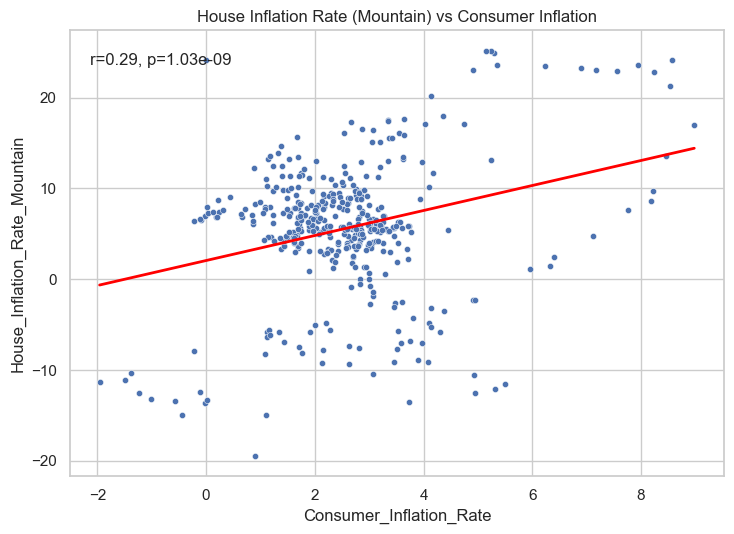

{'slope': np.float64(1.377016963698594), 'intercept': np.float64(2.057276044370045), 'r': np.float64(0.29219063816352986), 'p': np.float64(1.0345242142886432e-09), 'n': 420}


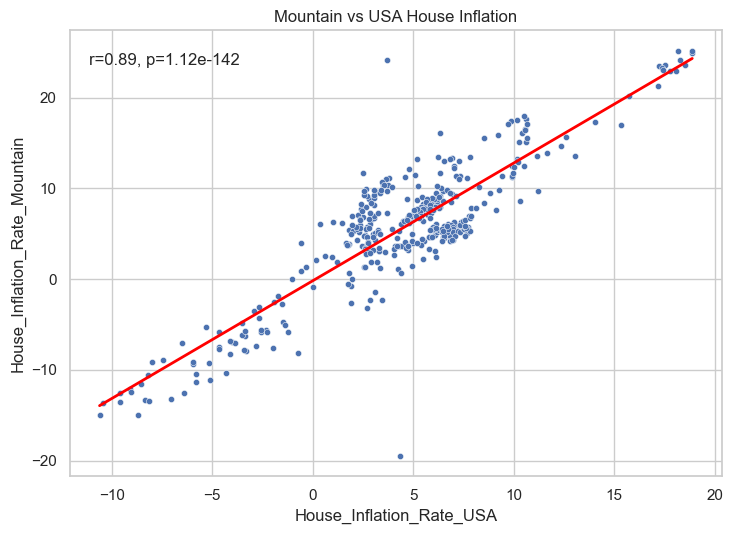

{'slope': np.float64(1.2970013185531089), 'intercept': np.float64(-0.1810482166627514), 'r': np.float64(0.8874253382405298), 'p': np.float64(1.1234714955869606e-142), 'n': 420}


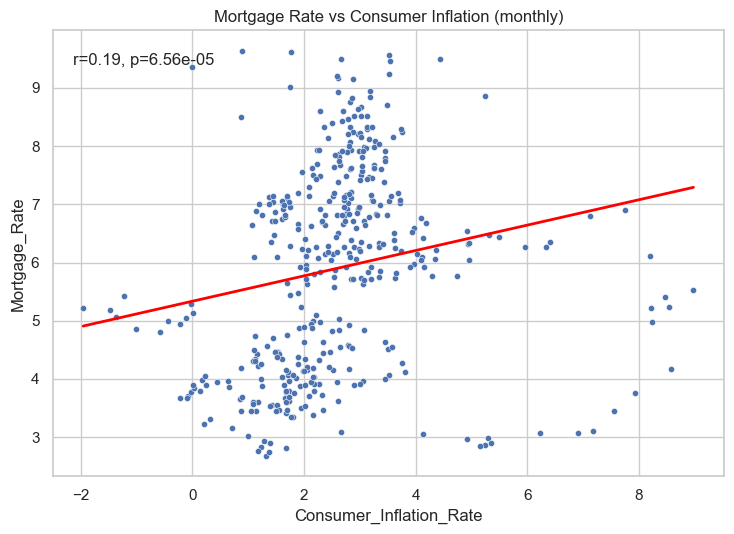

{'slope': np.float64(0.2178999693630044), 'intercept': np.float64(5.334726091119444), 'r': np.float64(0.19350366102780905), 'p': np.float64(6.562473210419268e-05), 'n': 420}


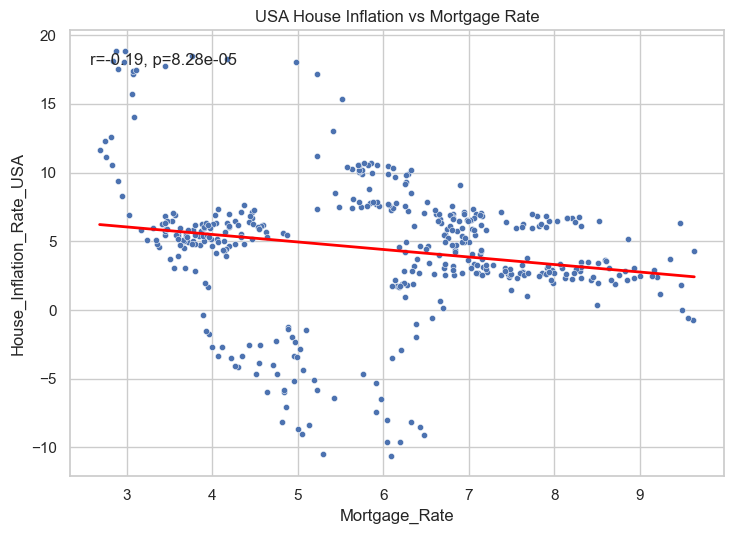

{'slope': np.float64(-0.5465362289559071), 'intercept': np.float64(7.687921391158325), 'r': np.float64(-0.1908633482641928), 'p': np.float64(8.280958402545042e-05), 'n': 420}


In [7]:
def reg_plot(frame: pd.DataFrame, x_col: str, y_col: str, title: str, file_name: str):
    clean = frame[[x_col, y_col]].dropna()
    fit = linregress(clean[x_col], clean[y_col])

    plt.figure(figsize=(7.5, 5.5))
    sns.scatterplot(data=clean, x=x_col, y=y_col, s=20)
    xs = np.linspace(clean[x_col].min(), clean[x_col].max(), 120)
    ys = fit.intercept + fit.slope * xs
    plt.plot(xs, ys, color="red", linewidth=2)
    plt.title(title)
    plt.text(0.03, 0.95, f"r={fit.rvalue:.2f}, p={fit.pvalue:.3g}", transform=plt.gca().transAxes, va="top")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / file_name, dpi=140)
    plt.show()

    print({"slope": fit.slope, "intercept": fit.intercept, "r": fit.rvalue, "p": fit.pvalue, "n": len(clean)})

reg_plot(df, "Consumer_Inflation_Rate", "House_Inflation_Rate_USA", "House Inflation Rate (USA) vs Consumer Inflation", "nb_reg_df_house_usa_vs_cpi.png")
reg_plot(df, "Consumer_Inflation_Rate", "House_Inflation_Rate_Mountain", "House Inflation Rate (Mountain) vs Consumer Inflation", "nb_reg_df_house_mountain_vs_cpi.png")
reg_plot(df, "House_Inflation_Rate_USA", "House_Inflation_Rate_Mountain", "Mountain vs USA House Inflation", "nb_reg_df_house_mountain_vs_usa.png")
reg_plot(df, "Consumer_Inflation_Rate", "Mortgage_Rate", "Mortgage Rate vs Consumer Inflation (monthly)", "nb_reg_df_mortgage_vs_cpi.png")
reg_plot(df, "Mortgage_Rate", "House_Inflation_Rate_USA", "USA House Inflation vs Mortgage Rate", "nb_reg_df_house_usa_vs_mortgage.png")

## 8) Individual correlations/regressions for `df2` (quarterly)
Equivalent to the R chunk for quarterly regional analysis.

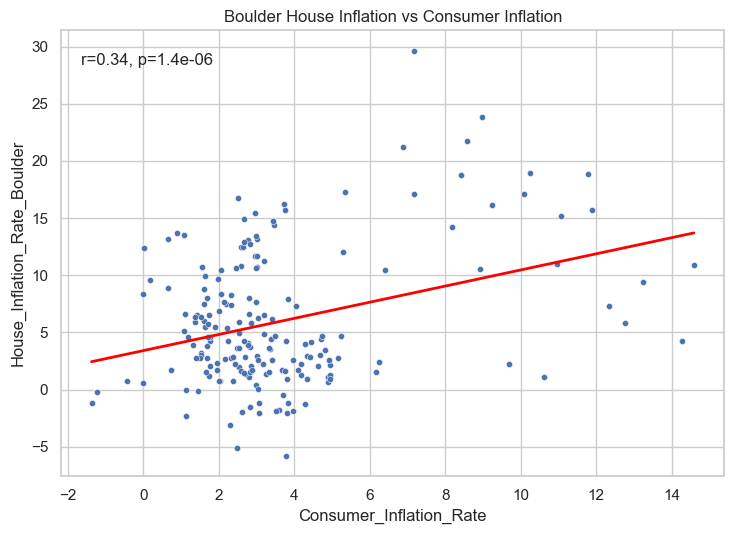

{'slope': np.float64(0.7050413685295969), 'intercept': np.float64(3.4149141936582046), 'r': np.float64(0.34000458777367676), 'p': np.float64(1.4000050146155648e-06), 'n': 192}


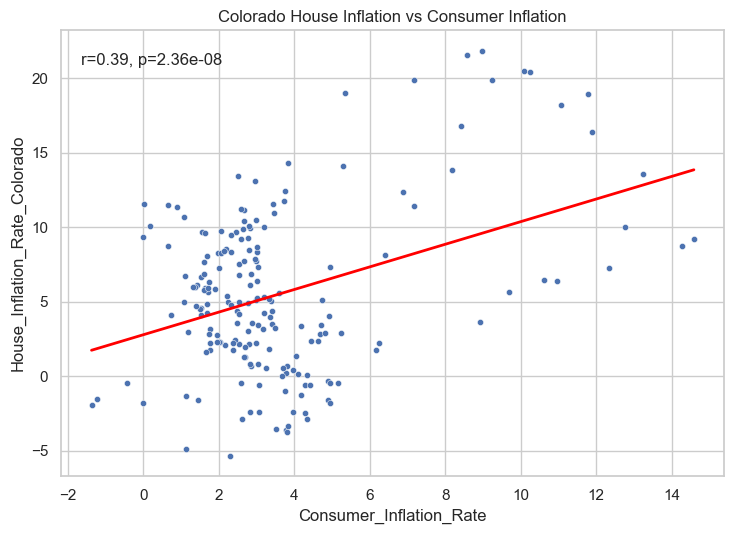

{'slope': np.float64(0.758248900279185), 'intercept': np.float64(2.795382493223502), 'r': np.float64(0.3894662319267762), 'p': np.float64(2.3586014065256495e-08), 'n': 192}


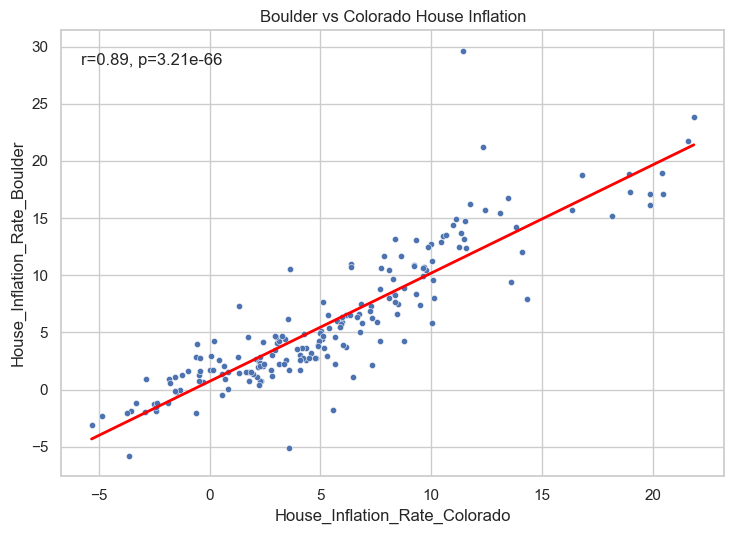

{'slope': np.float64(0.94642276157116), 'intercept': np.float64(0.723832395289862), 'r': np.float64(0.8885816366509498), 'p': np.float64(3.2098502627439175e-66), 'n': 192}


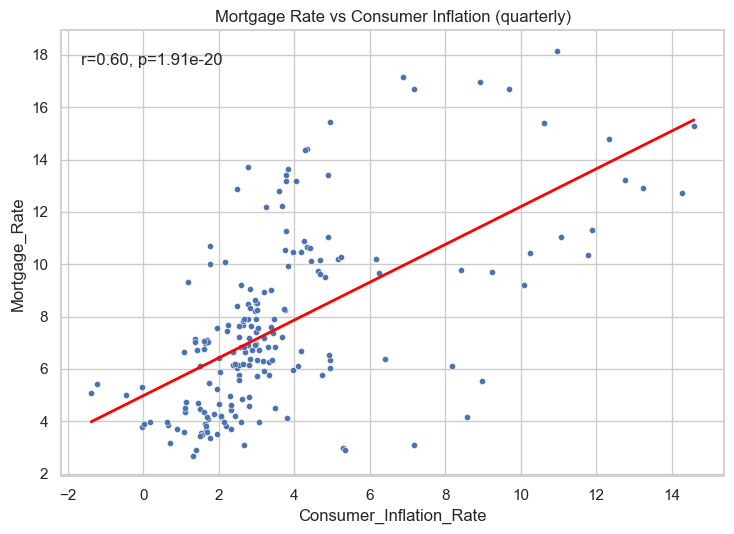

{'slope': np.float64(0.7222441805037105), 'intercept': np.float64(4.973563666291174), 'r': np.float64(0.6036404328226335), 'p': np.float64(1.9098764357599878e-20), 'n': 192}


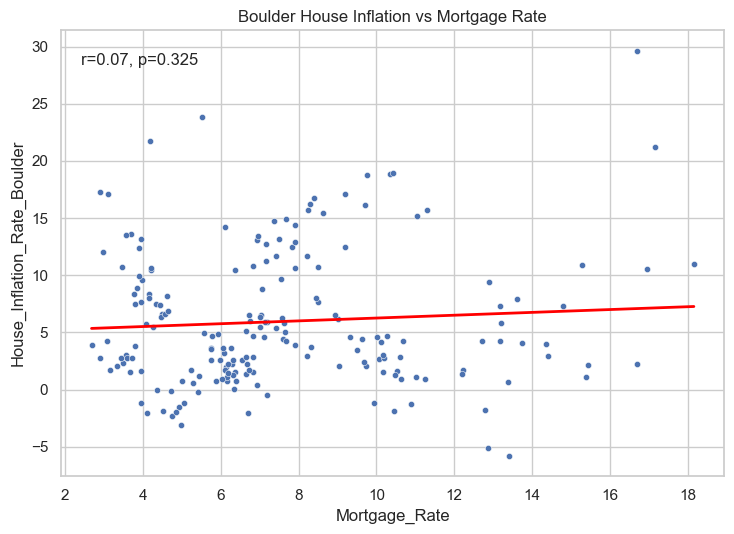

{'slope': np.float64(0.12382591899052232), 'intercept': np.float64(5.023598489126948), 'r': np.float64(0.07144757059571903), 'p': np.float64(0.32472181049846766), 'n': 192}


In [8]:
reg_plot(df2, "Consumer_Inflation_Rate", "House_Inflation_Rate_Boulder", "Boulder House Inflation vs Consumer Inflation", "nb_reg_df2_boulder_vs_cpi.png")
reg_plot(df2, "Consumer_Inflation_Rate", "House_Inflation_Rate_Colorado", "Colorado House Inflation vs Consumer Inflation", "nb_reg_df2_colorado_vs_cpi.png")
reg_plot(df2, "House_Inflation_Rate_Colorado", "House_Inflation_Rate_Boulder", "Boulder vs Colorado House Inflation", "nb_reg_df2_boulder_vs_colorado.png")
reg_plot(df2, "Consumer_Inflation_Rate", "Mortgage_Rate", "Mortgage Rate vs Consumer Inflation (quarterly)", "nb_reg_df2_mortgage_vs_cpi.png")
reg_plot(df2, "Mortgage_Rate", "House_Inflation_Rate_Boulder", "Boulder House Inflation vs Mortgage Rate", "nb_reg_df2_boulder_vs_mortgage.png")

## 9) Individual correlation/regression for `df1` (long monthly)
Equivalent to the R chunk for 1971+ mortgage vs inflation.

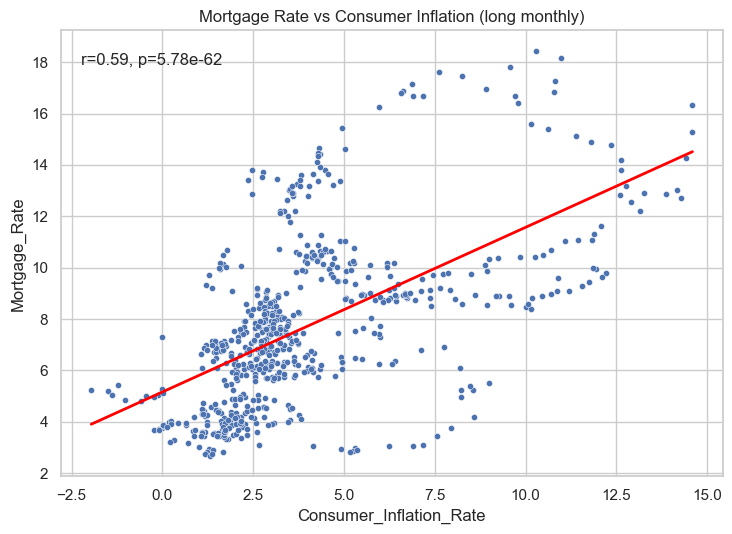

{'slope': np.float64(0.641123447534048), 'intercept': np.float64(5.161801707425906), 'r': np.float64(0.5857890064362967), 'p': np.float64(5.779840048693419e-62), 'n': 659}


In [9]:
reg_plot(df1, "Consumer_Inflation_Rate", "Mortgage_Rate", "Mortgage Rate vs Consumer Inflation (long monthly)", "nb_reg_df1_mortgage_vs_cpi.png")

## 10) K-means clustering on `df3` (all indexes)
Equivalent to first clustering chunk (`k=4,6,5`).

,CPI,HousingIndex_Colorado,HousingIndex_Denver,HousingIndex_Boulder,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,134.8,130.74,73.21,66.82,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,0
1,136.0,132.34,74.37,67.09,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,0
2,137.0,133.59,74.85,68.58,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,0
3,138.2,135.87,75.99,70.13,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,0
4,139.1,137.74,77.31,71.19,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,0


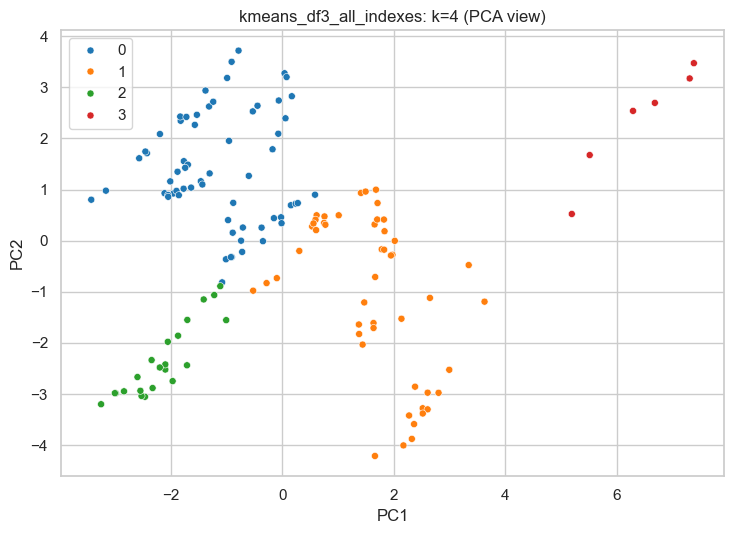

,CPI,HousingIndex_Colorado,HousingIndex_Denver,HousingIndex_Boulder,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,134.8,130.74,73.21,66.82,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,2
1,136.0,132.34,74.37,67.09,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,2
2,137.0,133.59,74.85,68.58,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,2
3,138.2,135.87,75.99,70.13,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,2
4,139.1,137.74,77.31,71.19,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,2


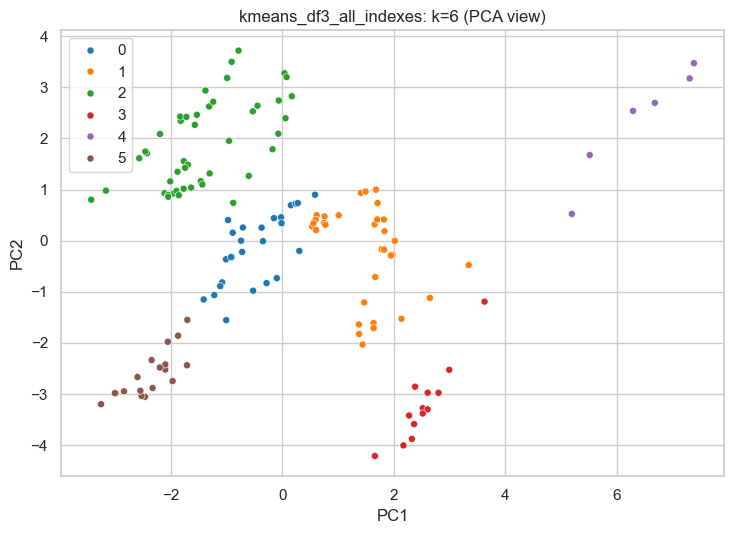

,CPI,HousingIndex_Colorado,HousingIndex_Denver,HousingIndex_Boulder,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,134.8,130.74,73.21,66.82,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,2
1,136.0,132.34,74.37,67.09,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,2
2,137.0,133.59,74.85,68.58,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,2
3,138.2,135.87,75.99,70.13,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,2
4,139.1,137.74,77.31,71.19,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,2


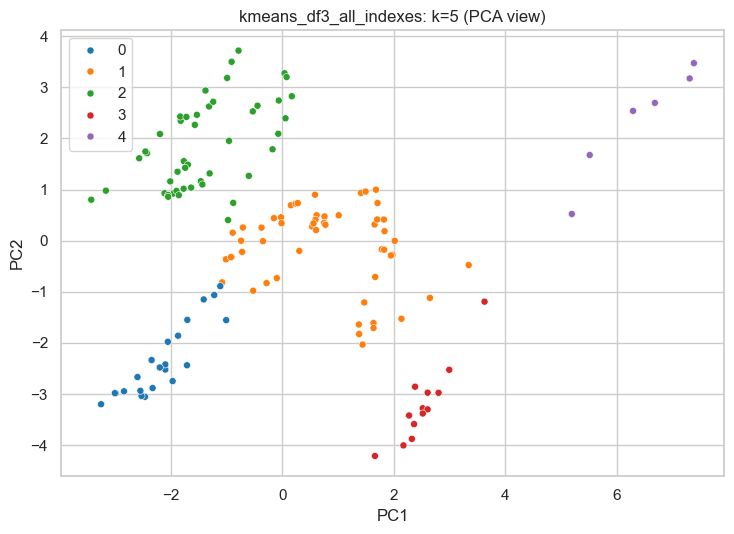

In [10]:
def run_kmeans_plot(frame: pd.DataFrame, cols: list[str], k: int, label: str):
    clean = frame[cols].dropna().reset_index(drop=True)
    scaler = StandardScaler()
    x = scaler.fit_transform(clean)

    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    cluster = km.fit_predict(x)

    pca = PCA(n_components=2, random_state=42)
    x2 = pca.fit_transform(x)

    clustered = clean.copy()
    clustered["cluster"] = cluster
    display(clustered.head())

    plt.figure(figsize=(7.5, 5.5))
    sns.scatterplot(x=x2[:, 0], y=x2[:, 1], hue=cluster, palette="tab10", s=26)
    plt.title(f"{label}: k={k} (PCA view)")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"nb_{label}_k{k}.png", dpi=140)
    plt.show()
    return clustered

all_cols_df3 = [
    "CPI", "HousingIndex_Colorado", "HousingIndex_Denver", "HousingIndex_Boulder", "Mortgage_Rate",
    "Consumer_Inflation_Rate", "House_Inflation_Rate_Colorado", "House_Inflation_Rate_Denver",
    "House_Inflation_Rate_Boulder", "House_Inflation_Rate_USA", "House_Inflation_Rate_Mountain"
]

clusterGroups4 = run_kmeans_plot(df3, all_cols_df3, 4, "kmeans_df3_all_indexes")
clusterGroups6 = run_kmeans_plot(df3, all_cols_df3, 6, "kmeans_df3_all_indexes")
clusterGroups5 = run_kmeans_plot(df3, all_cols_df3, 5, "kmeans_df3_all_indexes")

## 11) K-means clustering on `df4` (inflation-only subset)
Equivalent to second clustering chunk (`k=4,5,6`).

,Year,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,1991.25,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,0
1,1991.50,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,0
2,1991.75,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,0
3,1992.00,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,0
4,1992.25,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,0


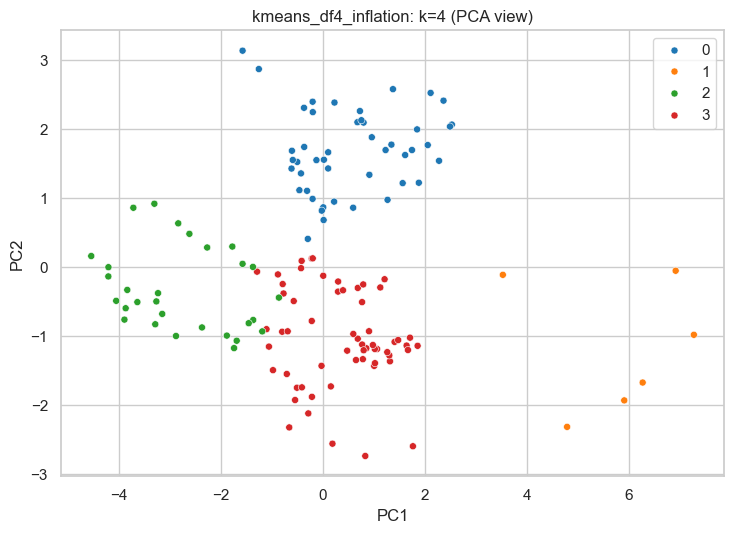

,Year,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,1991.25,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,0
1,1991.50,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,0
2,1991.75,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,0
3,1992.00,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,0
4,1992.25,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,0


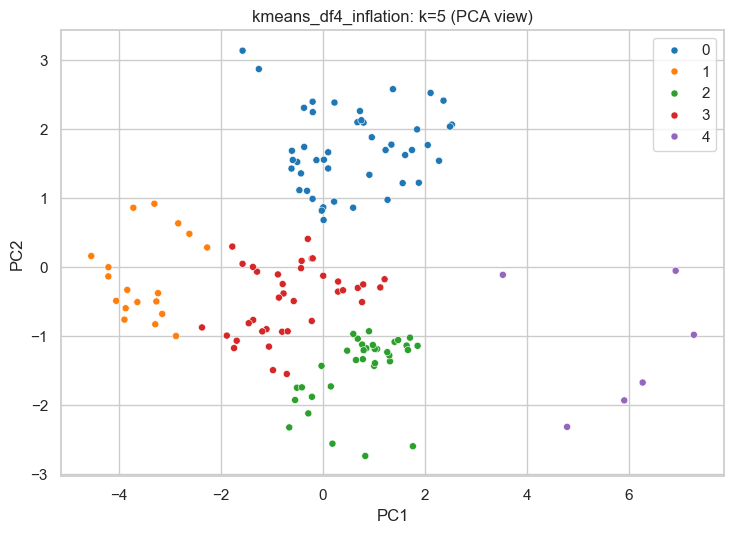

,Year,Mortgage_Rate,Consumer_Inflation_Rate,House_Inflation_Rate_Colorado,House_Inflation_Rate_Denver,House_Inflation_Rate_Boulder,House_Inflation_Rate_USA,House_Inflation_Rate_Mountain,cluster
0,1991.25,9.50,4.821151,2.936777,2.779728,3.484590,0.000000,-0.836987,4
1,1991.50,9.62,4.695920,3.414863,3.406563,4.420233,-0.710409,-8.110491,4
2,1991.75,9.01,3.396226,3.542086,3.212907,6.193868,2.486679,11.658489,4
3,1992.00,8.50,2.980626,5.138126,4.295910,7.676954,0.352423,6.127758,4
4,1992.25,8.94,3.189911,5.354138,5.600328,6.539958,2.304559,5.151455,4


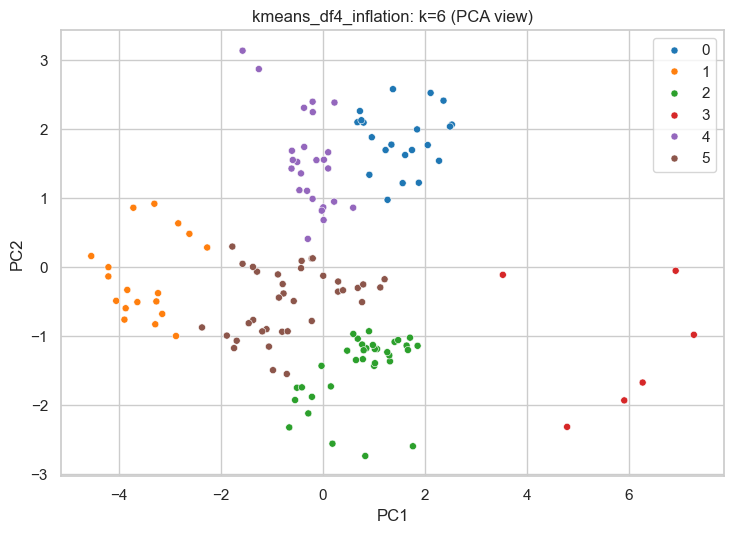

In [11]:
df4 = df3[[
    "Year", "Mortgage_Rate", "Consumer_Inflation_Rate", "House_Inflation_Rate_Colorado",
    "House_Inflation_Rate_Denver", "House_Inflation_Rate_Boulder", "House_Inflation_Rate_USA",
    "House_Inflation_Rate_Mountain"
]].copy()

clusterInflationGroups4 = run_kmeans_plot(df4, df4.columns.tolist(), 4, "kmeans_df4_inflation")
clusterInflationGroups5 = run_kmeans_plot(df4, df4.columns.tolist(), 5, "kmeans_df4_inflation")
clusterInflationGroups6 = run_kmeans_plot(df4, df4.columns.tolist(), 6, "kmeans_df4_inflation")

## 12) Analyze cluster-specific regressions for `df4` k=4 solution
Equivalent to the R chunk analyzing each cluster separately.

Cluster 0: n=46


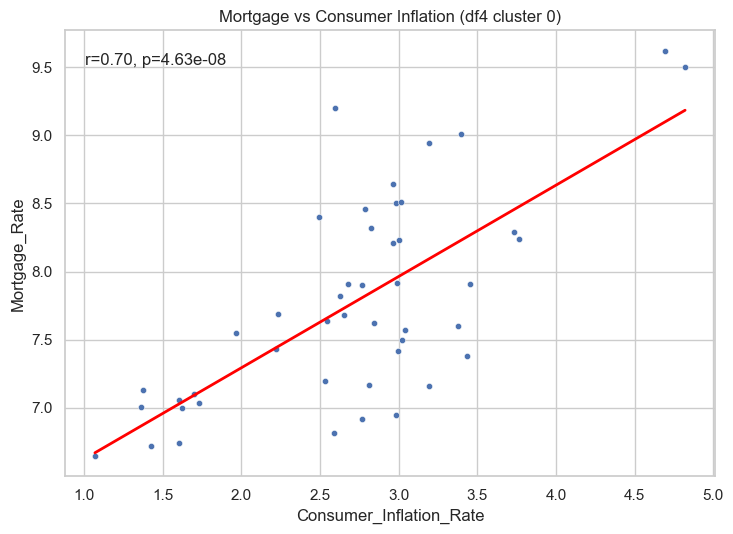

{'slope': np.float64(0.6694665200331723), 'intercept': np.float64(5.9556395536164475), 'r': np.float64(0.7046083858766289), 'p': np.float64(4.6257484108392924e-08), 'n': 46}
Years:
[1991.25, 1991.5, 1991.75, 1992.0, 1992.25, 1992.5, 1992.75, 1993.0, 1993.25, 1993.5, 1993.75, 1994.0, 1994.25, 1994.5, 1994.75, 1995.0, 1995.25, 1995.5, 1995.75, 1996.0, 1996.25, 1996.5, 1996.75, 1997.0, 1997.25, 1997.5, 1997.75, 1998.0, 1998.25, 1998.5, 1998.75, 1999.0, 1999.25, 1999.5, 1999.75, 2000.0, 2000.25, 2000.5, 2000.75, 2001.0, 2001.25, 2001.5, 2001.75, 2002.0, 2002.25, 2002.5]
Cluster 1: n=6


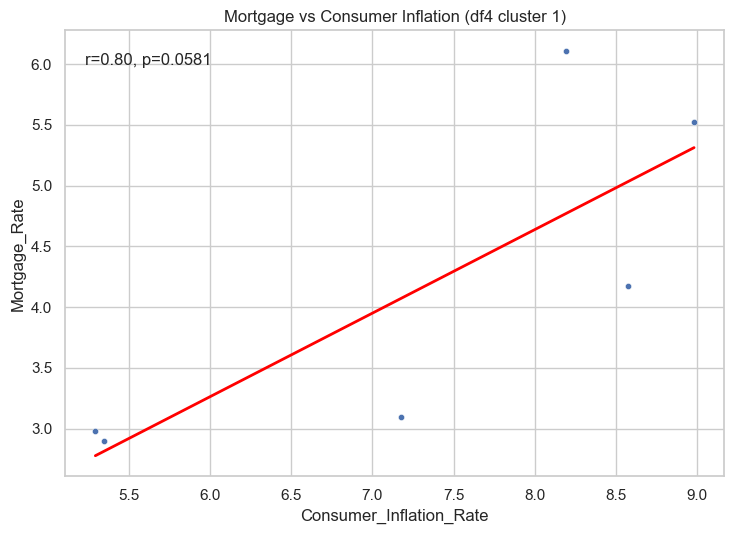

{'slope': np.float64(0.6880152343618662), 'intercept': np.float64(-0.8655480614430564), 'r': np.float64(0.7961578881304084), 'p': np.float64(0.05809242623963264), 'n': 6}
Years:
[2021.5, 2021.75, 2022.0, 2022.25, 2022.5, 2022.75]
Cluster 2: n=29


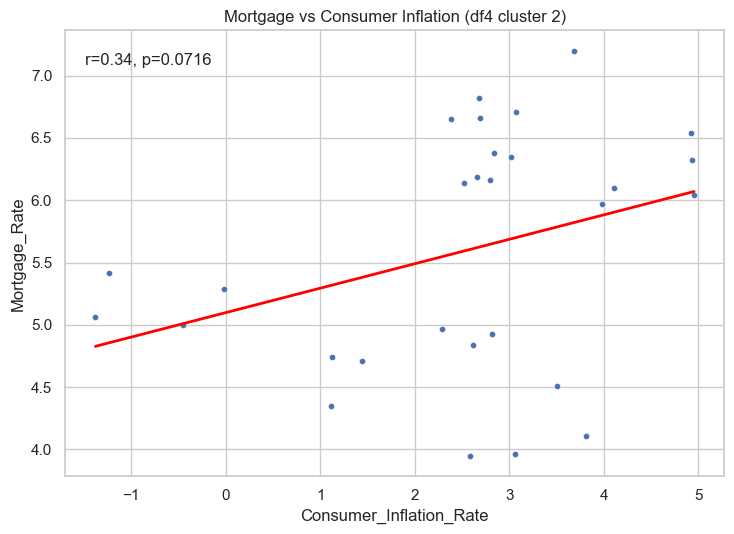

{'slope': np.float64(0.19623089195081514), 'intercept': np.float64(5.097929217517011), 'r': np.float64(0.33950802605287733), 'p': np.float64(0.07157173502132143), 'n': 29}
Years:
[2007.0, 2007.25, 2007.5, 2007.75, 2008.0, 2008.25, 2008.5, 2008.75, 2009.0, 2009.25, 2009.5, 2009.75, 2010.0, 2010.25, 2010.5, 2010.75, 2011.0, 2011.25, 2011.5, 2011.75, 2012.0, 2012.25, 2023.25, 2023.5, 2023.75, 2025.25, 2025.5, 2025.75, 2026.0]
Cluster 3: n=59


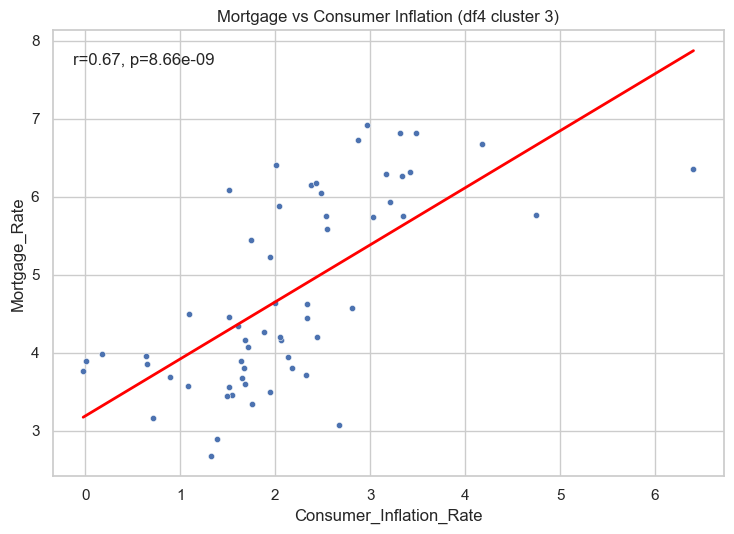

{'slope': np.float64(0.7310472830564287), 'intercept': np.float64(3.1892214735988738), 'r': np.float64(0.6658937773247935), 'p': np.float64(8.660502561009812e-09), 'n': 59}
Years:
[2002.75, 2003.0, 2003.25, 2003.5, 2003.75, 2004.0, 2004.25, 2004.5, 2004.75, 2005.0, 2005.25, 2005.5, 2005.75, 2006.0, 2006.25, 2006.5, 2006.75, 2012.5, 2012.75, 2013.0, 2013.25, 2013.5, 2013.75, 2014.0, 2014.25, 2014.5, 2014.75, 2015.0, 2015.25, 2015.5, 2015.75, 2016.0, 2016.25, 2016.5, 2016.75, 2017.0, 2017.25, 2017.5, 2017.75, 2018.0, 2018.25, 2018.5, 2018.75, 2019.0, 2019.25, 2019.5, 2019.75, 2020.0, 2020.25, 2020.5, 2020.75, 2021.0, 2021.25, 2023.0, 2024.0, 2024.25, 2024.5, 2024.75, 2025.0]


In [12]:
for cluster_id in sorted(clusterInflationGroups4["cluster"].unique()):
    cluster_df = clusterInflationGroups4[clusterInflationGroups4["cluster"] == cluster_id]
    print(f"Cluster {cluster_id}: n={len(cluster_df)}")
    reg_plot(
        cluster_df,
        "Consumer_Inflation_Rate",
        "Mortgage_Rate",
        f"Mortgage vs Consumer Inflation (df4 cluster {cluster_id})",
        f"nb_cluster_df4_{cluster_id}_mortgage_vs_cpi.png",
    )
    print("Years:")
    print(cluster_df["Year"].to_list())

## 13) K-means clustering for `df1` (mortgage + consumer inflation)
Equivalent to final clustering chunk (`k=4,5,6,3`).

,Year,Mortgage_Rate,Consumer_Inflation_Rate,cluster
0,1971.333333,7.31,5.985037,0
1,1971.416667,7.42,5.955335,0
2,1971.500000,7.53,2.962963,0
3,1971.583333,7.60,2.955665,0
4,1971.666667,7.70,2.948403,0


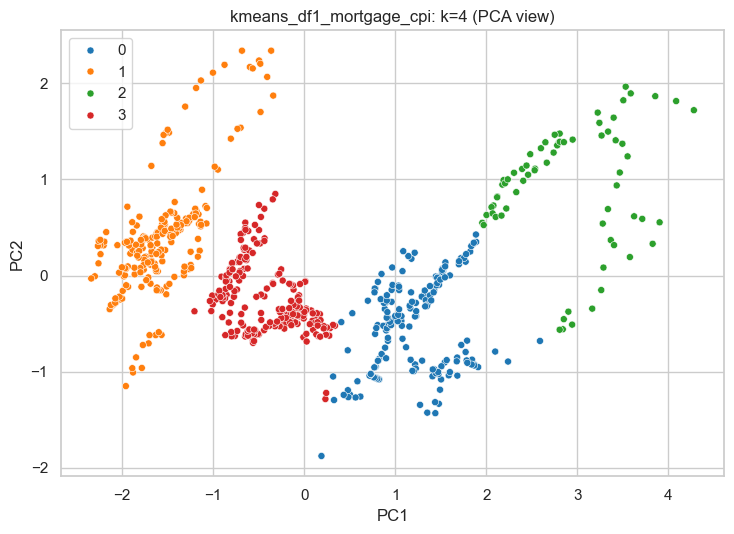

,Year,Mortgage_Rate,Consumer_Inflation_Rate,cluster
0,1971.333333,7.31,5.985037,4
1,1971.416667,7.42,5.955335,4
2,1971.500000,7.53,2.962963,4
3,1971.583333,7.60,2.955665,4
4,1971.666667,7.70,2.948403,4


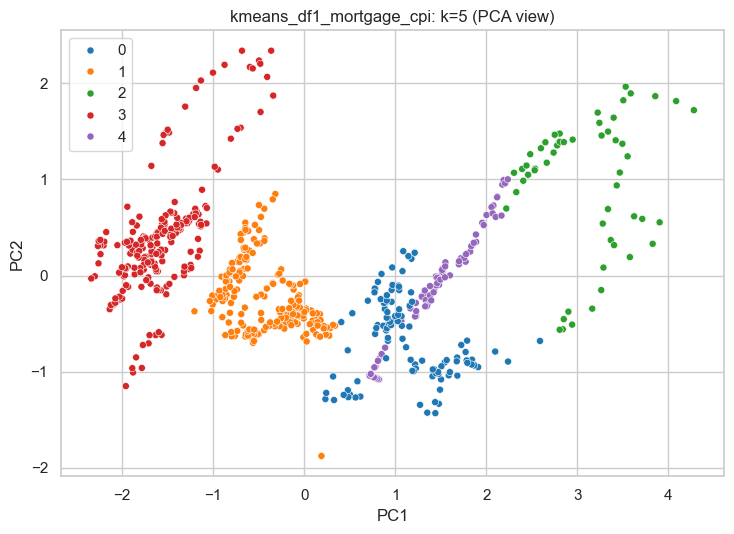

,Year,Mortgage_Rate,Consumer_Inflation_Rate,cluster
0,1971.333333,7.31,5.985037,5
1,1971.416667,7.42,5.955335,5
2,1971.500000,7.53,2.962963,5
3,1971.583333,7.60,2.955665,5
4,1971.666667,7.70,2.948403,5


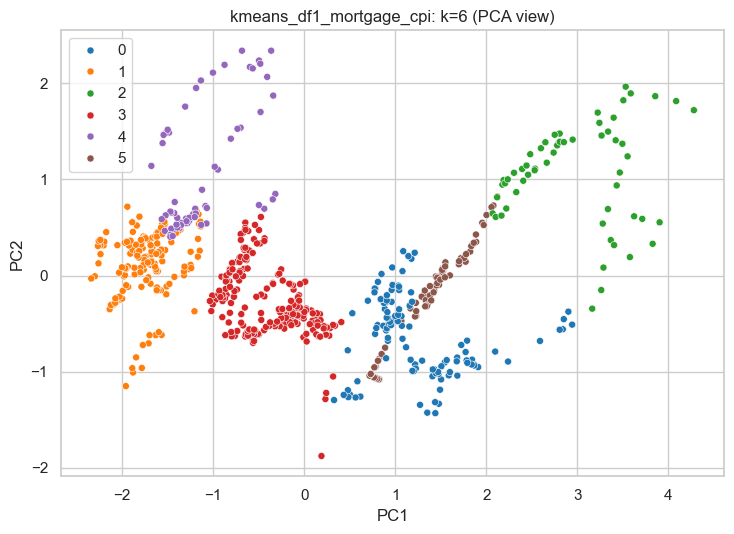

,Year,Mortgage_Rate,Consumer_Inflation_Rate,cluster
0,1971.333333,7.31,5.985037,2
1,1971.416667,7.42,5.955335,2
2,1971.500000,7.53,2.962963,2
3,1971.583333,7.60,2.955665,2
4,1971.666667,7.70,2.948403,2


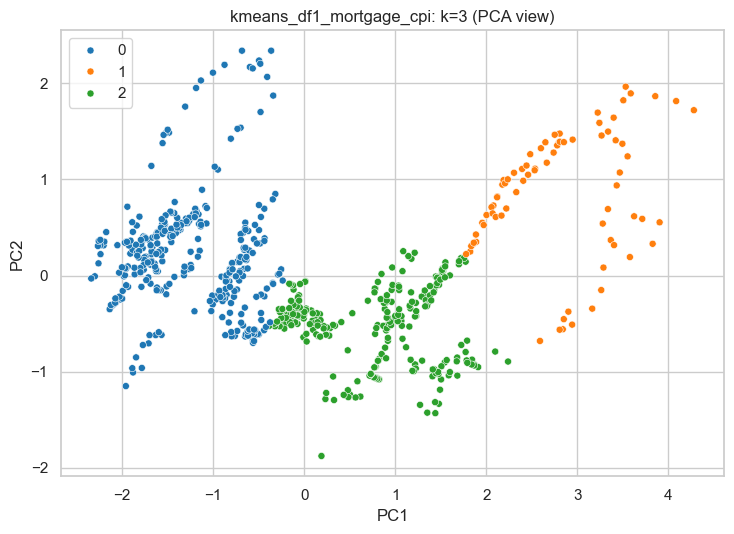

In [13]:
clusterCPIvsMortgageInflationGroups4 = run_kmeans_plot(df1, ["Year", "Mortgage_Rate", "Consumer_Inflation_Rate"], 4, "kmeans_df1_mortgage_cpi")
clusterCPIvsMortgageInflationGroups5 = run_kmeans_plot(df1, ["Year", "Mortgage_Rate", "Consumer_Inflation_Rate"], 5, "kmeans_df1_mortgage_cpi")
clusterCPIvsMortgageInflationGroups6 = run_kmeans_plot(df1, ["Year", "Mortgage_Rate", "Consumer_Inflation_Rate"], 6, "kmeans_df1_mortgage_cpi")
clusterCPIvsMortgageInflationGroups3 = run_kmeans_plot(df1, ["Year", "Mortgage_Rate", "Consumer_Inflation_Rate"], 3, "kmeans_df1_mortgage_cpi")

## 14) Analyze cluster-specific regressions for `df1` k=3 solution
Equivalent to the final R chunk.

Icluster 0: n=324


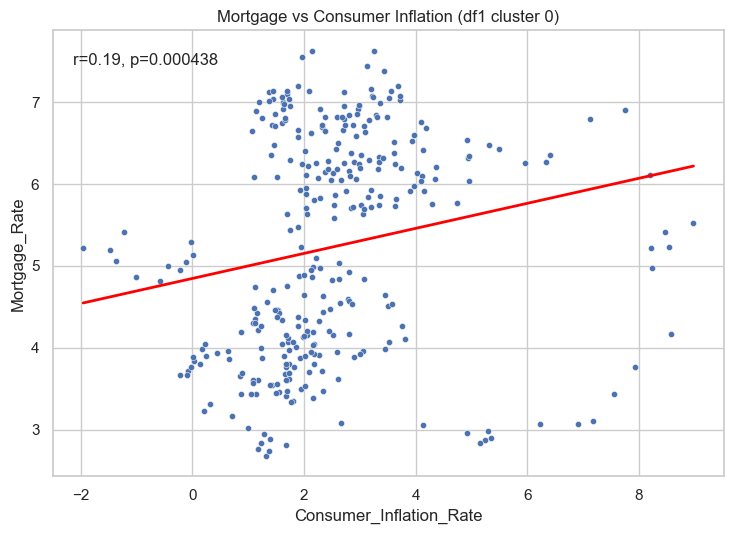

{'slope': np.float64(0.15294830695515152), 'intercept': np.float64(4.846541904088977), 'r': np.float64(0.19423003824436139), 'p': np.float64(0.0004378176261473026), 'n': 324}
Years:
[1997.9166666666667, 1998.0, 1998.0833333333333, 1998.1666666666667, 1998.25, 1998.3333333333333, 1998.4166666666667, 1998.5, 1998.5833333333333, 1998.6666666666667, 1998.75, 1998.8333333333333, 1998.9166666666667, 1999.0, 1999.0833333333333, 1999.1666666666667, 1999.25, 1999.3333333333333, 1999.4166666666667, 1999.5, 1999.5833333333333, 2001.0, 2001.0833333333333, 2001.1666666666667, 2001.25, 2001.3333333333333, 2001.4166666666667, 2001.5, 2001.5833333333333, 2001.6666666666667, 2001.75, 2001.8333333333333, 2001.9166666666667, 2002.0, 2002.0833333333333, 2002.1666666666667, 2002.25, 2002.3333333333333, 2002.4166666666667, 2002.5, 2002.5833333333333, 2002.6666666666667, 2002.75, 2002.8333333333333, 2002.9166666666667, 2003.0, 2003.0833333333333, 2003.1666666666667, 2003.25, 2003.3333333333333, 2003.41666666

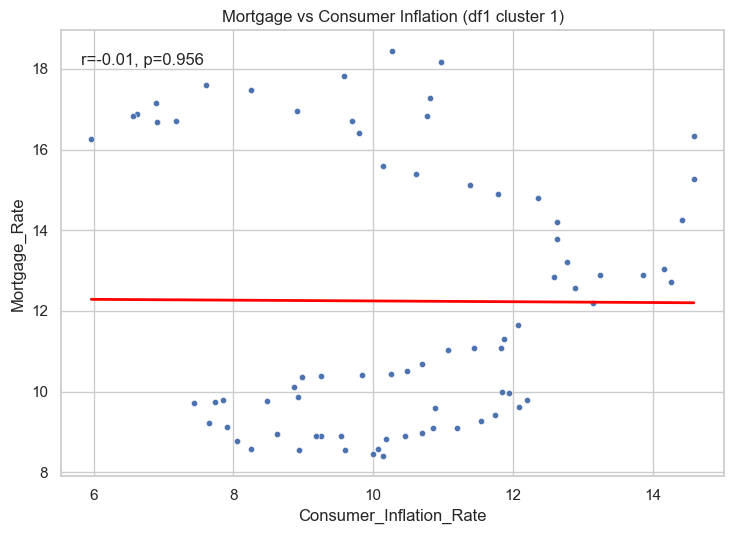

{'slope': np.float64(-0.009816336904346848), 'intercept': np.float64(12.344533425781767), 'r': np.float64(-0.006378487596173259), 'p': np.float64(0.9563891574457722), 'n': 76}
Years:
[1973.8333333333333, 1973.9166666666667, 1974.0, 1974.0833333333333, 1974.1666666666667, 1974.25, 1974.3333333333333, 1974.4166666666667, 1974.5, 1974.5833333333333, 1974.6666666666667, 1974.75, 1974.8333333333333, 1974.9166666666667, 1975.0, 1975.0833333333333, 1975.1666666666667, 1975.25, 1975.3333333333333, 1975.4166666666667, 1975.5, 1975.5833333333333, 1975.6666666666667, 1975.75, 1975.8333333333333, 1978.5, 1978.5833333333333, 1978.6666666666667, 1978.75, 1978.8333333333333, 1978.9166666666667, 1979.0, 1979.0833333333333, 1979.1666666666667, 1979.25, 1979.3333333333333, 1979.4166666666667, 1979.5, 1979.5833333333333, 1979.6666666666667, 1979.75, 1979.8333333333333, 1979.9166666666667, 1980.0, 1980.0833333333333, 1980.1666666666667, 1980.25, 1980.3333333333333, 1980.4166666666667, 1980.5, 1980.5833333

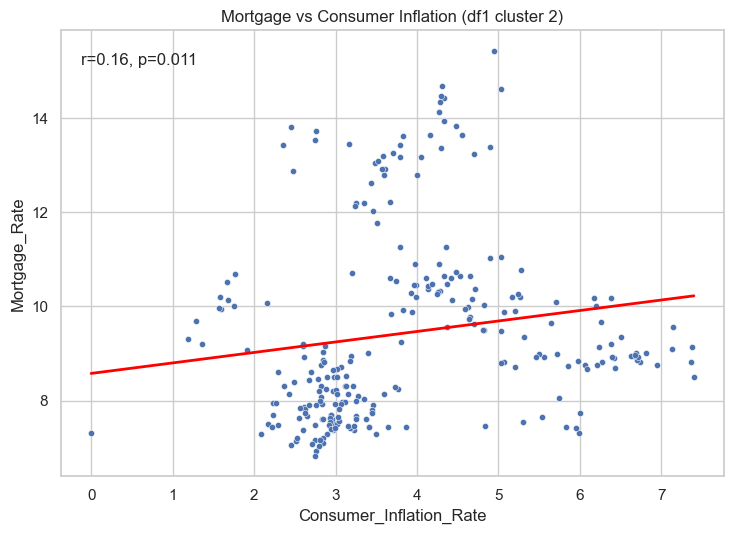

{'slope': np.float64(0.22265936545336962), 'intercept': np.float64(8.577417905326703), 'r': np.float64(0.15768169563295273), 'p': np.float64(0.011044435831504435), 'n': 259}
Years:
[1971.3333333333333, 1971.4166666666667, 1971.5, 1971.5833333333333, 1971.6666666666667, 1971.75, 1971.8333333333333, 1971.9166666666667, 1972.0, 1972.0833333333333, 1972.1666666666667, 1972.25, 1972.3333333333333, 1972.4166666666667, 1972.5, 1972.5833333333333, 1972.6666666666667, 1972.75, 1972.8333333333333, 1972.9166666666667, 1973.0, 1973.0833333333333, 1973.1666666666667, 1973.25, 1973.3333333333333, 1973.4166666666667, 1973.5, 1973.5833333333333, 1973.6666666666667, 1973.75, 1975.9166666666667, 1976.0, 1976.0833333333333, 1976.1666666666667, 1976.25, 1976.3333333333333, 1976.4166666666667, 1976.5, 1976.5833333333333, 1976.6666666666667, 1976.75, 1976.8333333333333, 1976.9166666666667, 1977.0, 1977.0833333333333, 1977.1666666666667, 1977.25, 1977.3333333333333, 1977.4166666666667, 1977.5, 1977.583333333

In [14]:
for cluster_id in sorted(clusterCPIvsMortgageInflationGroups3["cluster"].unique()):
    icluster = clusterCPIvsMortgageInflationGroups3[clusterCPIvsMortgageInflationGroups3["cluster"] == cluster_id]
    print(f"Icluster {cluster_id}: n={len(icluster)}")
    reg_plot(
        icluster,
        "Consumer_Inflation_Rate",
        "Mortgage_Rate",
        f"Mortgage vs Consumer Inflation (df1 cluster {cluster_id})",
        f"nb_cluster_df1_{cluster_id}_mortgage_vs_cpi.png",
    )
    print("Years:")
    print(icluster["Year"].to_list())

## 15) Optional: Save key tables

In [15]:
df.to_csv(OUTPUT_DIR / "nb_df_monthly.csv", index=False)
df1.to_csv(OUTPUT_DIR / "nb_df1_monthly.csv", index=False)
df2.to_csv(OUTPUT_DIR / "nb_df2_quarterly.csv", index=False)
df3.to_csv(OUTPUT_DIR / "nb_df3_merged.csv", index=False)
print("Saved notebook output tables to outputs/")

Saved notebook output tables to outputs/
